In [42]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf


In [4]:
data_dir = Path(r"D:\final project\main data")
out_dir = Path(r"D:\final project\output")

fig_dir = out_dir / "figures"
tab_dir = out_dir / "tables"

fig_dir.mkdir(parents=True, exist_ok=True)
tab_dir.mkdir(parents=True, exist_ok=True)

In [7]:
# Strategy-level dataset
df_strat = pd.read_parquet(data_dir / "data_structures.parquet")
df_opt = pd.read_parquet(data_dir / "data_opt.parquet")
df_rv = pd.read_parquet(data_dir / "future_moments_SPX.parquet")
df_vix = pd.read_parquet(data_dir / "vix.parquet")
df_eod = pd.read_csv(data_dir / "ALL_eod.csv")


In [10]:
df_strat["quote_date"] = pd.to_datetime(df_strat["quote_date"])
df_opt["quote_date"]   = pd.to_datetime(df_opt["quote_date"])
df_vix["quote_date"]   = pd.to_datetime(df_vix["quote_date"])
df_rv["date"]          = pd.to_datetime(df_rv["date"])
df_eod["Date"]         = pd.to_datetime(df_eod["Date"])

def clean_time(x):
    return pd.to_datetime(str(x)).strftime("%H:%M:%S")

df_strat["time"] = df_strat["quote_time"].apply(clean_time)
df_opt["time"]   = df_opt["quote_time"].apply(clean_time)
df_vix["time"]   = df_vix["quote_time"].apply(clean_time)
df_rv["time"]    = df_rv["time"].apply(clean_time)


In [12]:
def summary_stats(df, group, value):
    return (
        df.groupby(group)[value]
        .agg(
            mean="mean",
            median="median",
            q25=lambda x: x.quantile(.25),
            q75=lambda x: x.quantile(.75)
        )
    )


def bar_summary(ax, stats, title, ylabel, labels=None):
    x = np.arange(len(stats))

    ax.bar(x, stats["mean"], color="steelblue", alpha=.75, label="Mean")

    for i in range(len(stats)):
        ax.hlines(stats["median"].iloc[i], i-.20, i+.20, color="red",
                  linewidth=2, label="Median" if i == 0 else None)

        ax.hlines(stats["q25"].iloc[i], i-.35, i-.20, color="orange",
                  linewidth=2, label="25%" if i == 0 else None)

        ax.hlines(stats["q75"].iloc[i], i+.20, i+.35, color="green",
                  linewidth=2, label="75%" if i == 0 else None)
        ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.axhline(0, linewidth=.7, color="gray")
    ax.grid(axis="y", linestyle="--", alpha=.3)

    ax.set_xticks(x)
    ax.set_xticklabels(
        labels if labels is not None else stats.index,
        rotation=45,
        fontsize=8
    )

    ax.legend(fontsize=7)

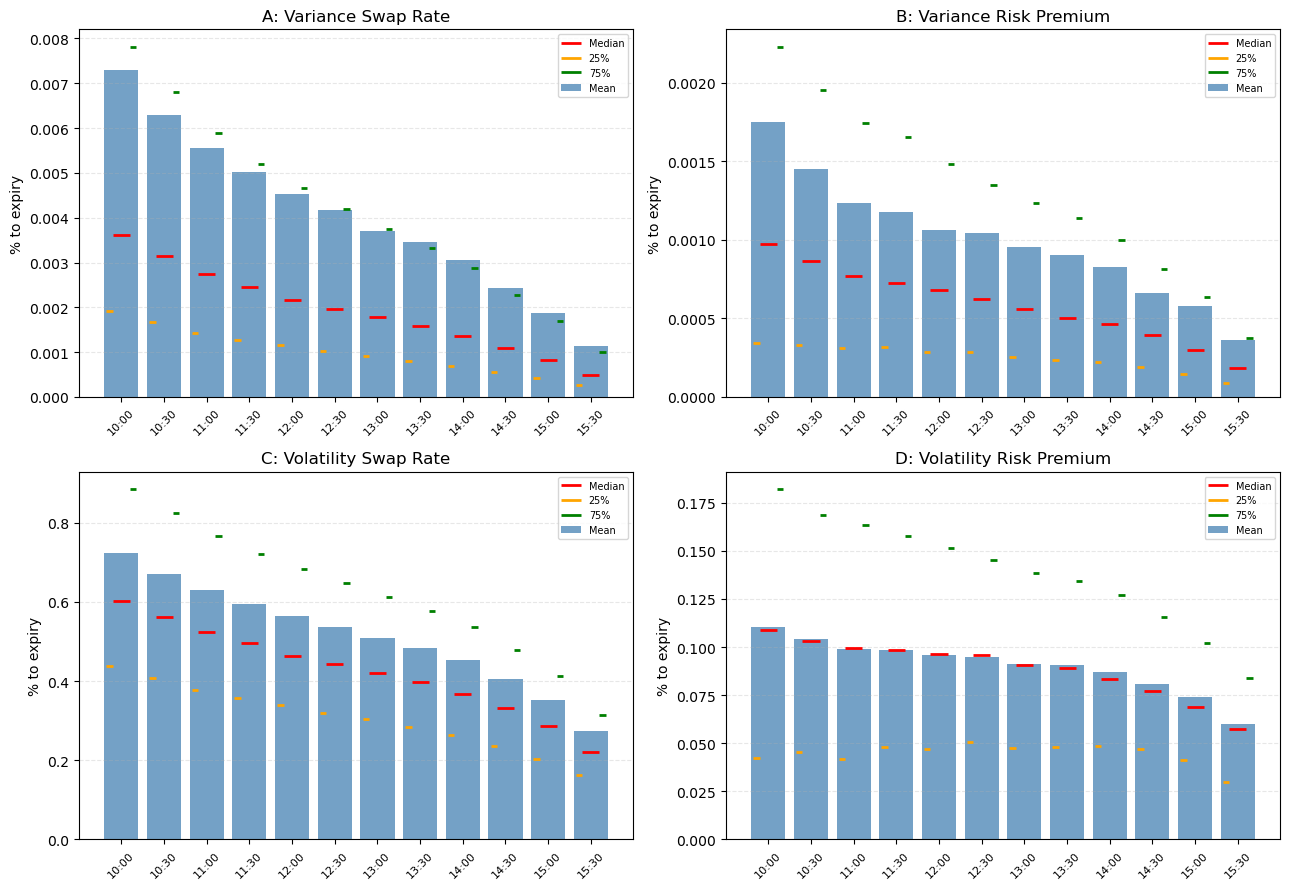

In [14]:
vrp = df_vix[df_vix["dts"] == 0].copy()

vrp = vrp.merge(
    df_rv[["date", "time", "SPX_lrv"]],
    left_on=["quote_date", "time"],
    right_on=["date", "time"]
)

vrp = vrp[vrp["root"] == "SPXW"].copy()

vrp["vix_pct"]      = vrp["vix"] * 100
vrp["vrp_pct"]      = (vrp["vix"] - vrp["SPX_lrv"]/1e5) * 100
vrp["vix_volapct"]  = np.sqrt(vrp["vix"]) * 100
vrp["vrp_volapct"]  = (
    np.sqrt(vrp["vix"]) -
    np.sqrt(vrp["SPX_lrv"]/1e5)
) * 100
times = [
    "10:00:00","10:30:00","11:00:00","11:30:00",
    "12:00:00","12:30:00","13:00:00","13:30:00",
    "14:00:00","14:30:00","15:00:00","15:30:00"
]

specs = {
    "vix_pct": "A: Variance Swap Rate",
    "vrp_pct": "B: Variance Risk Premium",
    "vix_volapct": "C: Volatility Swap Rate",
    "vrp_volapct": "D: Volatility Risk Premium"
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (var, title) in zip(axes.flat, specs.items()):

    temp = vrp[vrp["time"].isin(times)]

    stats = summary_stats(temp, "time", var).reindex(times)

    bar_summary(
        ax,
        stats,
        title,
        "% to expiry",
        [t[:5] for t in times]
    )
    plt.tight_layout()

plt.savefig(
    fig_dir / "Figure1_VRP.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

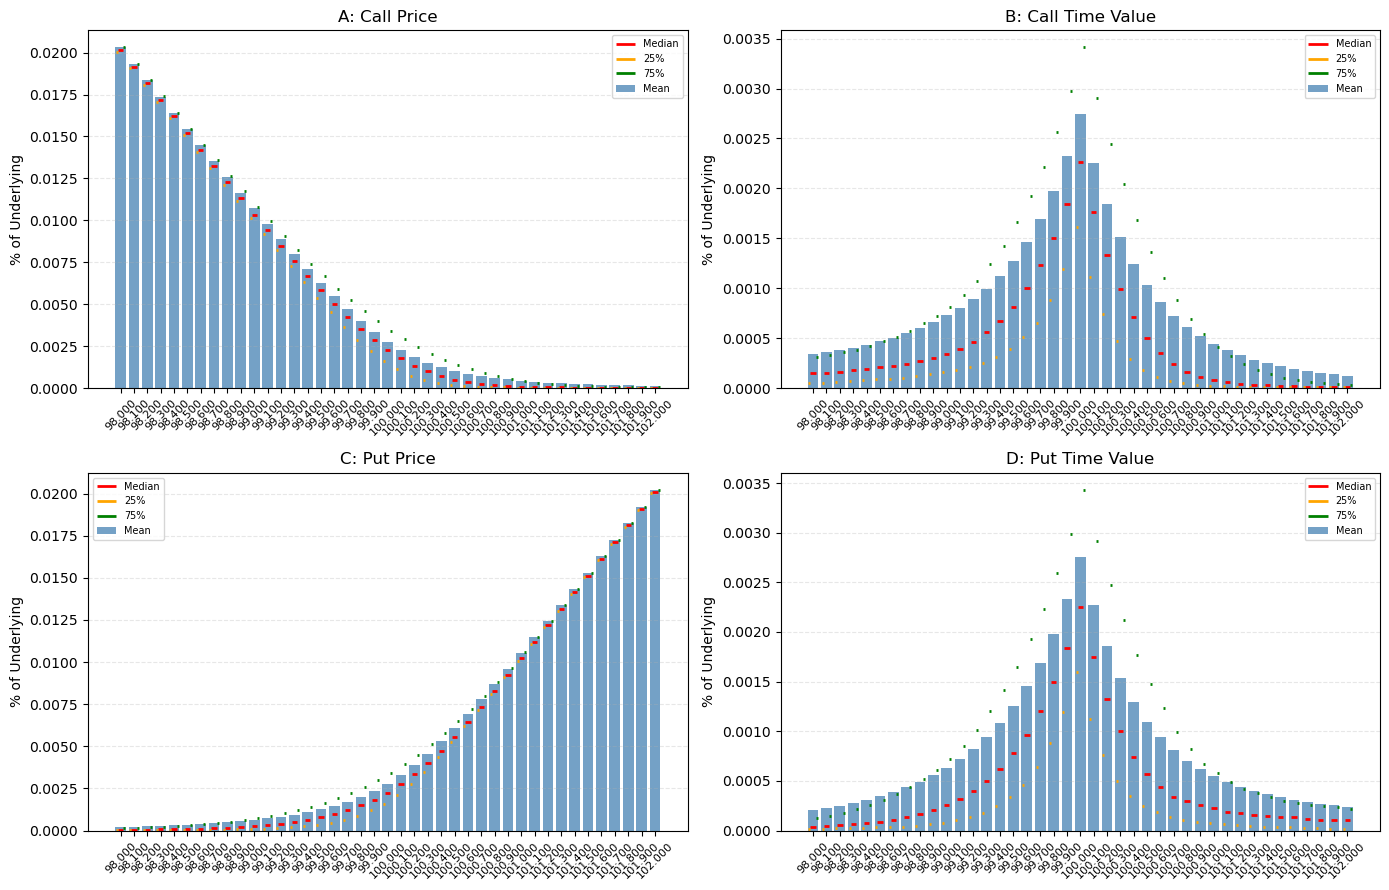

In [41]:
opt10 = df_opt[df_opt["time"] == "10:00:00"].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

specs = [
    ("C", "mid", "A: Call Price"),
    ("C", "tv",  "B: Call Time Value"),
    ("P", "mid", "C: Put Price"),
    ("P", "tv",  "D: Put Time Value")
]

for ax, (otype, var, title) in zip(axes.flat, specs):

    temp = opt10[opt10["option_type"] == otype]

    stats = summary_stats(temp, "mnes", var)

    labels = [
        f"{m/1000:.3f}"
        for m in stats.index
    ]
    bar_summary(
        ax,
        stats,
        title,
        "% of Underlying",
        labels
    )

plt.tight_layout()

plt.savefig(
    fig_dir / "Figure2_Option_Prices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

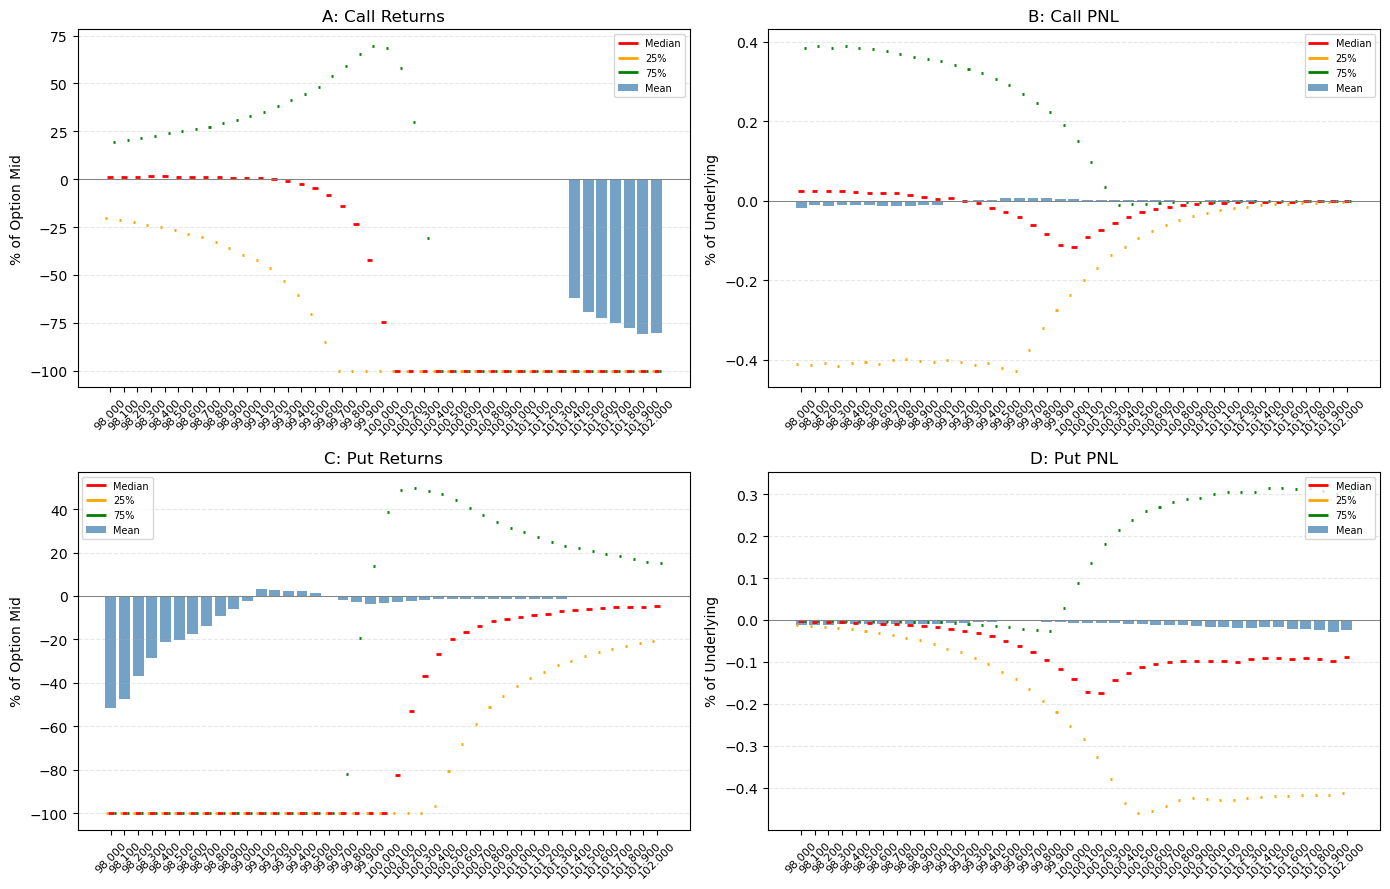

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

specs = [
    ("C", "reth",     "A: Call Returns", "% of Option Mid"),
    ("C", "reth_und", "B: Call PNL",     "% of Underlying"),
    ("P", "reth",     "C: Put Returns",   "% of Option Mid"),
    ("P", "reth_und", "D: Put PNL",       "% of Underlying")
]

for ax, (otype, var, title, ylabel) in zip(axes.flat, specs):

    temp = opt10[
        opt10["option_type"] == otype
    ]

    stats = summary_stats(temp, "mnes", var)

    labels = [
        f"{m/1000:.3f}"
        for m in stats.index
    ]

    bar_summary(
        ax,
        stats,
        title,
        ylabel,
        labels
    )
    plt.tight_layout()

plt.savefig(
    fig_dir / "Figure3_Option_Returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

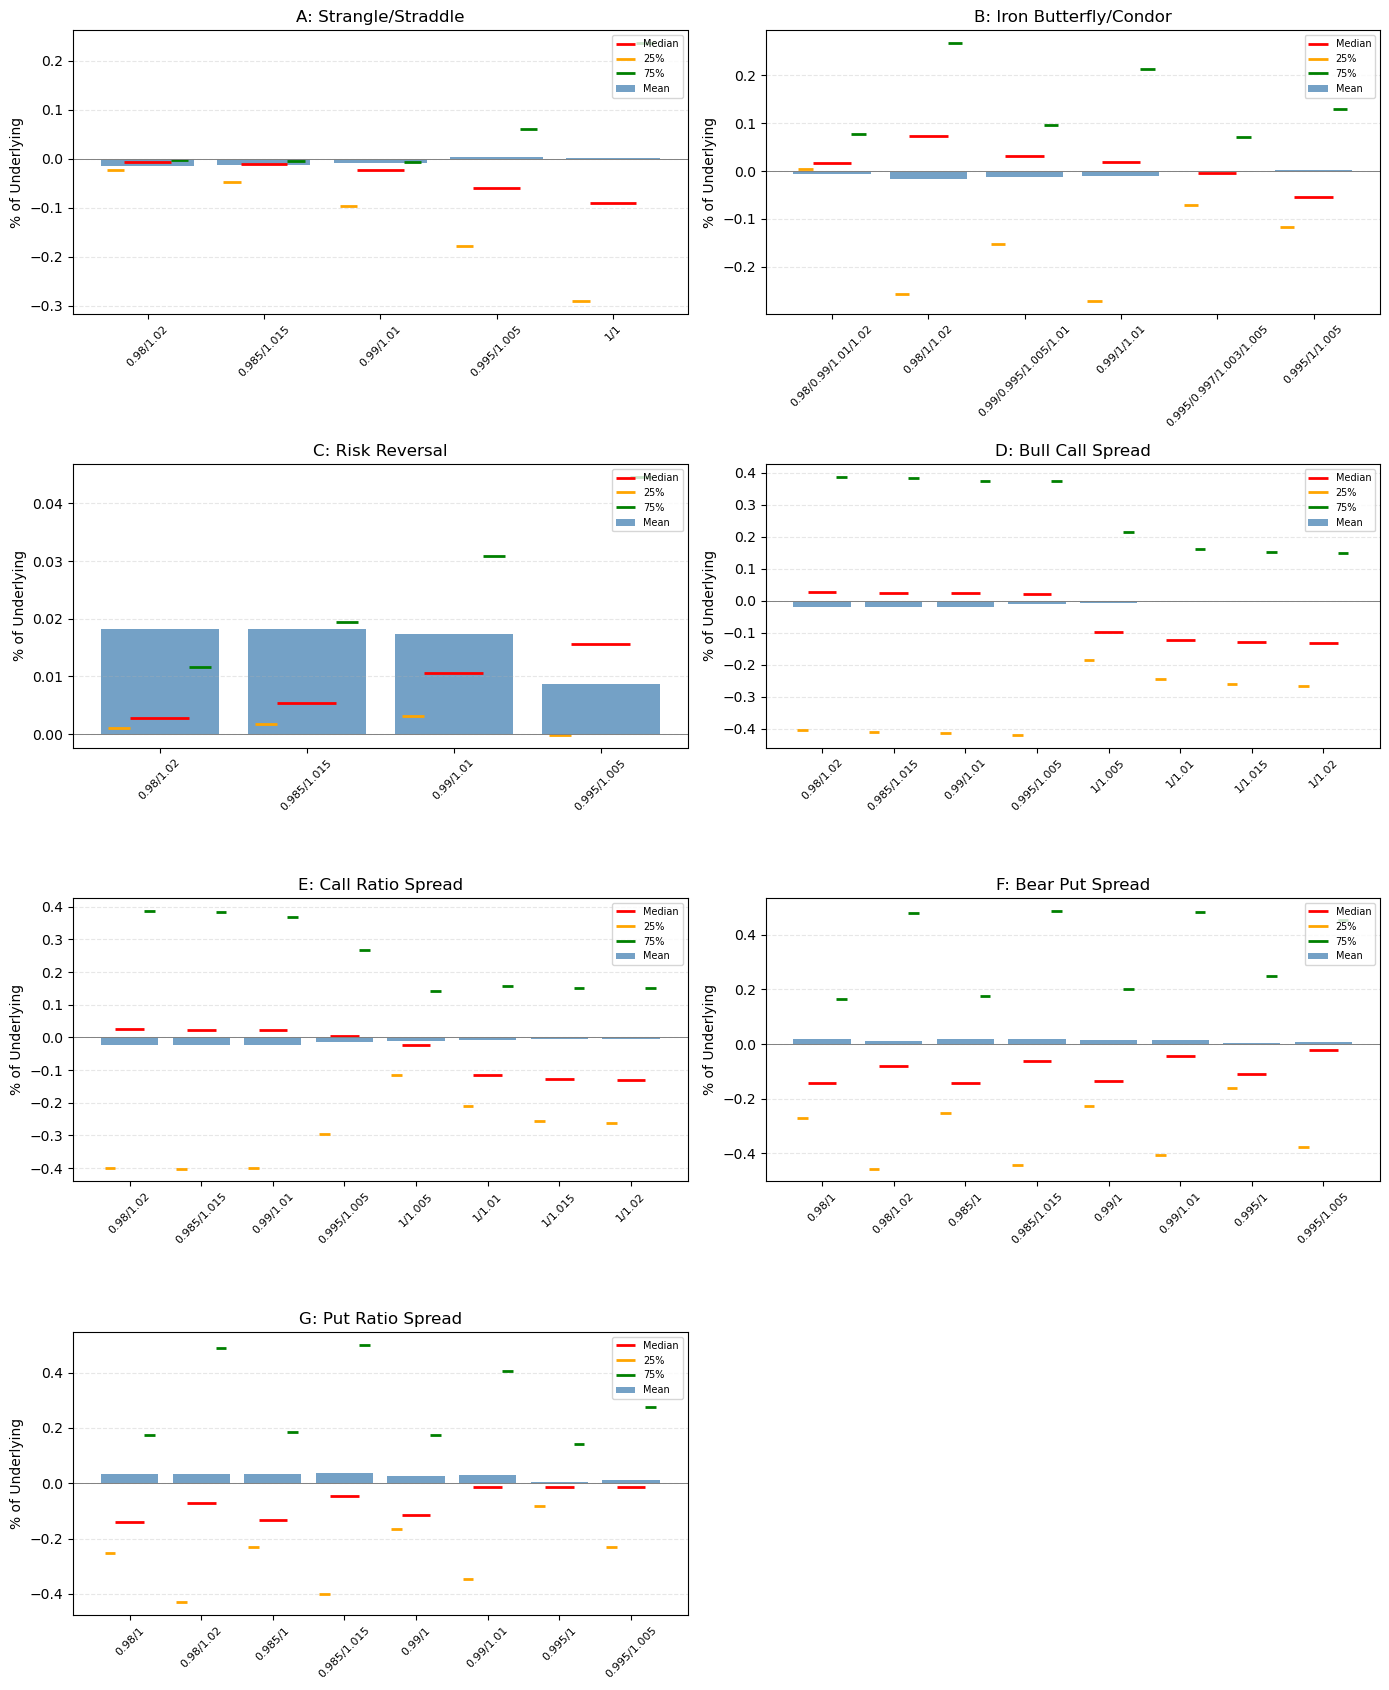

In [23]:
STRATEGY_LABELS = {
    "strangle": "Strangle/Straddle",
    "iron_condor": "Iron Butterfly/Condor",
    "risk_reversal": "Risk Reversal",
    "bull_call_spread": "Bull Call Spread",
    "call_ratio_spread": "Call Ratio Spread",
    "bear_put_spread": "Bear Put Spread",
    "put_ratio_spread": "Put Ratio Spread"
}

strat10 = df_strat[
    df_strat["time"] == "10:00:00"
].copy()

strat10["mnes"] = strat10["mnes"].astype(str)

fig, axes = plt.subplots(4, 2, figsize=(14, 17))
axes = axes.flat

for i, (strategy, label) in enumerate(
    STRATEGY_LABELS.items()
):

    temp = strat10[
        strat10["option_type"] == strategy
    ]

    stats = summary_stats(
        temp,
        "mnes",
        "reth_und"
    )

    bar_summary(
        axes[i],
        stats,
        f"{chr(65+i)}: {label}",
        "% of Underlying"
    )

axes[7].axis("off")

plt.tight_layout()

plt.savefig(
    fig_dir / "Figure4_Static_Strategies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
# ============================================================
# TABLE 1 — STATIC OPTION STRATEGY PERFORMANCE
# ============================================================

near_atm = {
    "strangle": ["1/1", "0.995/1.005", "0.99/1.01"],
    "iron_condor": ["0.995/1/1.005", "0.99/1/1.01",
                    "0.995/0.997/1.003/1.005", "0.99/0.995/1.005/1.01"],
    "risk_reversal": ["0.995/1.005", "0.99/1.01"],
    "bull_call_spread": ["1/1.005", "1/1.01", "0.995/1.005", "0.99/1.01"],
    "call_ratio_spread": ["1/1.005", "1/1.01", "0.995/1.005", "0.99/1.01"],
    "bear_put_spread": ["0.995/1", "0.99/1", "0.995/1.005", "0.99/1.01"],
    "put_ratio_spread": ["0.995/1", "0.99/1", "0.995/1.005", "0.99/1.01"]
}

rows = []

for strategy, label in STRATEGY_LABELS.items():
    temp = strat10[strat10["option_type"] == strategy]

    for mnes in near_atm[strategy]:
        s = temp.loc[temp["mnes"] == mnes, "reth_und"].dropna()

        if s.empty:
            continue

        rows.append({
            "Strategy": label,
            "Moneyness": mnes,
            "Count": len(s),
            "Mean": s.mean(),
            "Volatility": s.std(),
            "Min": s.min(),
            "1%": s.quantile(.01),
            "25%": s.quantile(.25),
            "50%": s.median(),
            "75%": s.quantile(.75),
            "99%": s.quantile(.99),
            "Max": s.max(),
            "Skew": s.skew(),
            "SR, p.a.": s.mean() / s.std() * np.sqrt(252)
        })

table1 = pd.DataFrame(rows)

# Display
display(table1.round({
    "Mean": 4, "Volatility": 2, "Min": 2, "1%": 2,
    "25%": 2, "50%": 2, "75%": 2, "99%": 2,
    "Max": 2, "Skew": 2, "SR, p.a.": 2
}))

# Save
table1.to_csv(
    tab_dir / "Table1_Static_Strategy_Performance.csv",
    index=False
)

,Strategy,Moneyness,Count,Mean,Volatility,Min,1%,25%,50%,75%,99%,Max,Skew,"SR, p.a."
0,Strangle/Straddle,1/1,952,0.0019,0.54,-2.69,-1.02,-0.29,-0.09,0.24,1.81,2.96,0.95,0.06
1,Strangle/Straddle,0.995/1.005,953,0.0041,0.46,-2.70,-0.85,-0.18,-0.06,0.06,1.71,2.90,1.36,0.14
2,Strangle/Straddle,0.99/1.01,953,-0.0083,0.36,-2.75,-0.78,-0.10,-0.02,-0.01,1.49,2.73,1.72,-0.37
3,Iron Butterfly/Condor,0.995/1/1.005,952,0.0022,0.16,-0.50,-0.25,-0.12,-0.05,0.13,0.35,0.43,0.49,0.22
4,Iron Butterfly/Condor,0.99/1/1.01,952,-0.0102,0.30,-1.00,-0.65,-0.27,0.02,0.21,0.59,0.83,-0.10,-0.53
5,Iron Butterfly/Condor,0.995/0.997/1.003/1.005,953,-0.0009,0.08,-0.20,-0.15,-0.07,-0.00,0.07,0.16,0.18,0.05,-0.17
6,Iron Butterfly/Condor,0.99/0.995/1.005/1.01,953,-0.0124,0.18,-0.50,-0.44,-0.15,0.03,0.10,0.30,0.40,-0.58,-1.10
7,Risk Reversal,0.995/1.005,953,0.0087,0.62,-3.48,-1.85,-0.00,0.02,0.04,2.15,5.36,1.02,0.22
8,Risk Reversal,0.99/1.01,953,0.0174,0.44,-3.00,-1.33,0.00,0.01,0.03,1.66,4.92,2.36,0.63
9,Bull Call Spread,1/1.005,953,-0.0060,0.20,-0.43,-0.24,-0.18,-0.10,0.21,0.35,0.50,0.51,-0.47


In [27]:
break_df = strat10.copy()

break_df["post"] = np.select(
    [
        break_df["quote_date"] <= "2022-04-14",
        break_df["quote_date"] >= "2022-05-11"
    ],
    [0, 1],
    default=np.nan
)

break_df = break_df.dropna(
    subset=["post"]
)

break_df["post"] = break_df["post"].astype(int)


rows = []

for strategy, label in STRATEGY_LABELS.items():

    d = break_df[
        break_df["option_type"] == strategy
    ].copy()
    pre = d[d["post"] == 0]["reth_und"]
    post = d[d["post"] == 1]["reth_und"]

    model = smf.ols(
        "reth_und ~ post + C(mnes)",
        data=d
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": d["quote_date"]}
    )

    rows.append({
        "Strategy": label,
        "Pre Mean": pre.mean(),
        "Post Mean": post.mean(),
        "Delta": model.params["post"],
        "t": model.tvalues["post"],
        "p-value": model.pvalues["post"],
        "Vol Ratio": post.std()/pre.std(),
        "N Pre": len(pre),
        "N Post": len(post)
    })
table2 = pd.DataFrame(rows)

display(table2.round(4))

table2.to_csv(
    tab_dir / "Table2_2022_Structural_Break.csv",
    index=False
)

,Strategy,Pre Mean,Post Mean,Delta,t,p-value,Vol Ratio,N Pre,N Post
0,Strangle/Straddle,-0.0085,-0.0097,-0.0012,-0.0525,0.9581,0.9145,2952,1745
1,Iron Butterfly/Condor,-0.0094,-0.0010,0.0084,0.5899,0.5552,1.0670,3541,2094
2,Risk Reversal,0.0241,0.0049,-0.0192,-0.8164,0.4143,0.8291,2362,1396
3,Bull Call Spread,-0.0123,-0.0024,0.0099,0.3126,0.7546,1.0602,4724,2792
4,Call Ratio Spread,-0.0188,0.0001,0.0189,0.6897,0.4904,1.0369,4724,2792
5,Bear Put Spread,0.0190,-0.0022,-0.0213,-0.6516,0.5147,1.0523,4067,2660
6,Put Ratio Spread,0.0381,0.0055,-0.0331,-1.2204,0.2223,1.0340,4067,2660


In [29]:
# Helper functions for transaction costs

def parse_levels(x):
    return sorted(float(v) for v in str(x).split("/"))


def mi(x):
    return int(round(x * 1e5))


def get_legs(strategy, m):
    x = parse_levels(m)

    if len(x) < 2:
        return []

    l, h = x[0], x[-1]

    if strategy == "strangle":
        return [("P", mi(l), 1), ("C", mi(h), 1)]

    if strategy == "risk_reversal":
        return [("P", mi(l), -1), ("C", mi(h), 1)]

    if strategy == "bull_call_spread":
        return [("C", mi(l), 1), ("C", mi(h), -1)]

    if strategy == "call_ratio_spread":
        return [("C", mi(l), 1), ("C", mi(h), -2)]

    if strategy == "bear_put_spread":
        return [("P", mi(l), -1), ("P", mi(h), 1)]

    if strategy == "put_ratio_spread":
        return [("P", mi(l), -2), ("P", mi(h), 1)]

    if strategy == "iron_condor":
        if len(x) == 3:
            m = x[1]
            return [
                ("P", mi(l), 1),
                ("P", mi(m), -1),
                ("C", mi(m), -1),
                ("C", mi(h), 1)
            ]

        if len(x) == 4:
            ml, mh = x[1], x[2]
            return [
                ("P", mi(l), 1),
                ("P", mi(ml), -1),
                ("C", mi(mh), -1),
                ("C", mi(h), 1)
            ]

    return []

99500
[('P', 99500, 1), ('C', 100500, 1)]


In [31]:
s = strat10[
    strat10["option_type"]
    .isin(STRATEGY_LABELS)
].copy()


o = df_opt[
    df_opt["time"] == "10:00:00"
][
    ["quote_date","time",
     "option_type","mnes","bas"]
].copy()


o["mnes"] = o["mnes"].astype(int)

o = (
    o.groupby(
        ["quote_date","time",
         "option_type","mnes"],
        as_index=False
    )["bas"]
    .mean()
)
lookup = {
    (
        r.quote_date,
        r.time,
        str(r.option_type),
        int(r.mnes)
    ): float(r.bas)

    for r in o.itertuples()
}


def half_spread(row):

    total = 0

    for ot, m, qty in get_legs(
        row["option_type"],
        row["mnes"]
    ):

        bas = lookup.get(
            (
                row["quote_date"],
                row["time"],
                ot,
                m
            ),
            np.nan
        )

        if pd.isna(bas):
            return np.nan

        total += abs(qty)*bas

    return .5*total


s["spread"] = s.apply(
    half_spread,
    axis=1
)

s = s.dropna(
    subset=["spread"]
)
s["pnl_mid"] = s["reth_und"]
s["pnl_ba"] = s["pnl_mid"] - s["spread"]
s["pnl_net"] = s["pnl_ba"] - .005

s["turnover"] = (
    s["mid"].abs()
    +
    s["spread"]
)


daily = (
    s.groupby(
        ["option_type","quote_date"],
        as_index=False
    )[
        [
            "pnl_mid",
            "pnl_ba",
            "pnl_net",
            "turnover"
        ]
    ]
    .mean()
)

In [33]:
# ============================================================
# TABLE 3
# ============================================================

def sharpe(x):
    return x.mean()/x.std()*np.sqrt(252)


def ES(x, q=.01):
    cutoff = x.quantile(q)
    return -x[x <= cutoff].mean()


rows = []

for strategy, label in STRATEGY_LABELS.items():

    d = daily[
        daily["option_type"] == strategy
    ]

    net = d["pnl_net"]

    es = ES(net)

    turn = d["turnover"].mean()*100

    rows.append({
        "Strategy": label,
        "Mean Mid": d["pnl_mid"].mean(),
        "Mean B/A": d["pnl_ba"].mean(),
        "Mean B/A+0.5bp": net.mean(),
        "SR Mid": sharpe(d["pnl_mid"]),
        "SR B/A+0.5bp": sharpe(net),
        "Turnover (bps)": turn,
        "SR/Turnover": sharpe(net)/turn,
        "ES1%": es,
        "Mean/ES1%": net.mean()/es,
        "Obs": len(d)
    })


table3 = pd.DataFrame(rows)

display(table3.round(4))

table3.to_csv(
    tab_dir / "Table3_Implementable_PNL.csv",
    index=False
)

,Strategy,Mean Mid,Mean B/A,Mean B/A+0.5bp,SR Mid,SR B/A+0.5bp,Turnover (bps),SR/Turnover,ES1%,Mean/ES1%,Obs
0,Strangle/Straddle,-0.0059,-0.0060,-0.0110,-0.2706,-0.5053,0.2410,-2.0969,1.4230,-0.0077,953
1,Iron Butterfly/Condor,-0.0073,-0.0075,-0.0125,-0.5559,-0.9563,0.3101,-3.0836,0.5792,-0.0217,953
2,Risk Reversal,0.0157,0.0156,0.0106,0.6539,0.4418,0.0267,16.5694,1.6010,0.0066,953
3,Bull Call Spread,-0.0101,-0.0104,-0.0154,-0.3463,-0.5282,0.7911,-0.6677,0.9041,-0.0171,953
4,Call Ratio Spread,-0.0140,-0.0144,-0.0194,-0.5496,-0.7594,0.7495,-1.0133,1.2088,-0.0160,953
5,Bear Put Spread,0.0138,0.0135,0.0085,0.4802,0.2959,0.6290,0.4705,0.8269,0.0103,952
6,Put Ratio Spread,0.0251,0.0248,0.0198,1.0642,0.8382,0.5740,1.4603,0.7101,0.0279,952


In [35]:
# ============================================================
# TABLE 4
# ============================================================

def max_dd(x):
    cum = x.cumsum()
    return -(cum-cum.cummax()).min()


rows = []

for strategy, label in STRATEGY_LABELS.items():

    x = daily[
        daily["option_type"] == strategy
    ]["pnl_net"].dropna()

    rows.append({
        "Strategy": label,
        "Skewness": x.skew(),
        "ES1%": ES(x),
        "Max DD": max_dd(x),
        "Worst Day": x.min(),
        "Worst 5-Day": x.rolling(5).sum().min(),
        "Loss Prob (%)": (x < 0).mean()*100,
        "Obs": len(x)
    })


table4 = pd.DataFrame(rows)

display(table4.round(4))

table4.to_csv(
    tab_dir / "Table4_Tail_Risk.csv",
    index=False
)

,Strategy,Skewness,ES1%,Max DD,Worst Day,Worst 5-Day,Loss Prob (%),Obs
0,Strangle/Straddle,1.4743,1.4230,19.5464,-2.5113,-7.0941,69.2550,953
1,Iron Butterfly/Condor,-0.4157,0.5792,15.5132,-0.6583,-1.6477,45.7503,953
2,Risk Reversal,3.0584,1.6010,7.2302,-2.7656,-4.3888,41.8678,953
3,Bull Call Spread,0.3719,0.9041,20.3637,-0.9755,-3.9473,55.4040,953
4,Call Ratio Spread,-0.2848,1.2088,22.7531,-2.5148,-4.4097,54.0399,953
5,Bear Put Spread,0.6696,0.8269,8.2091,-0.8641,-2.9679,61.7647,952
6,Put Ratio Spread,0.6769,0.7101,6.1109,-0.8726,-2.5504,58.8235,952


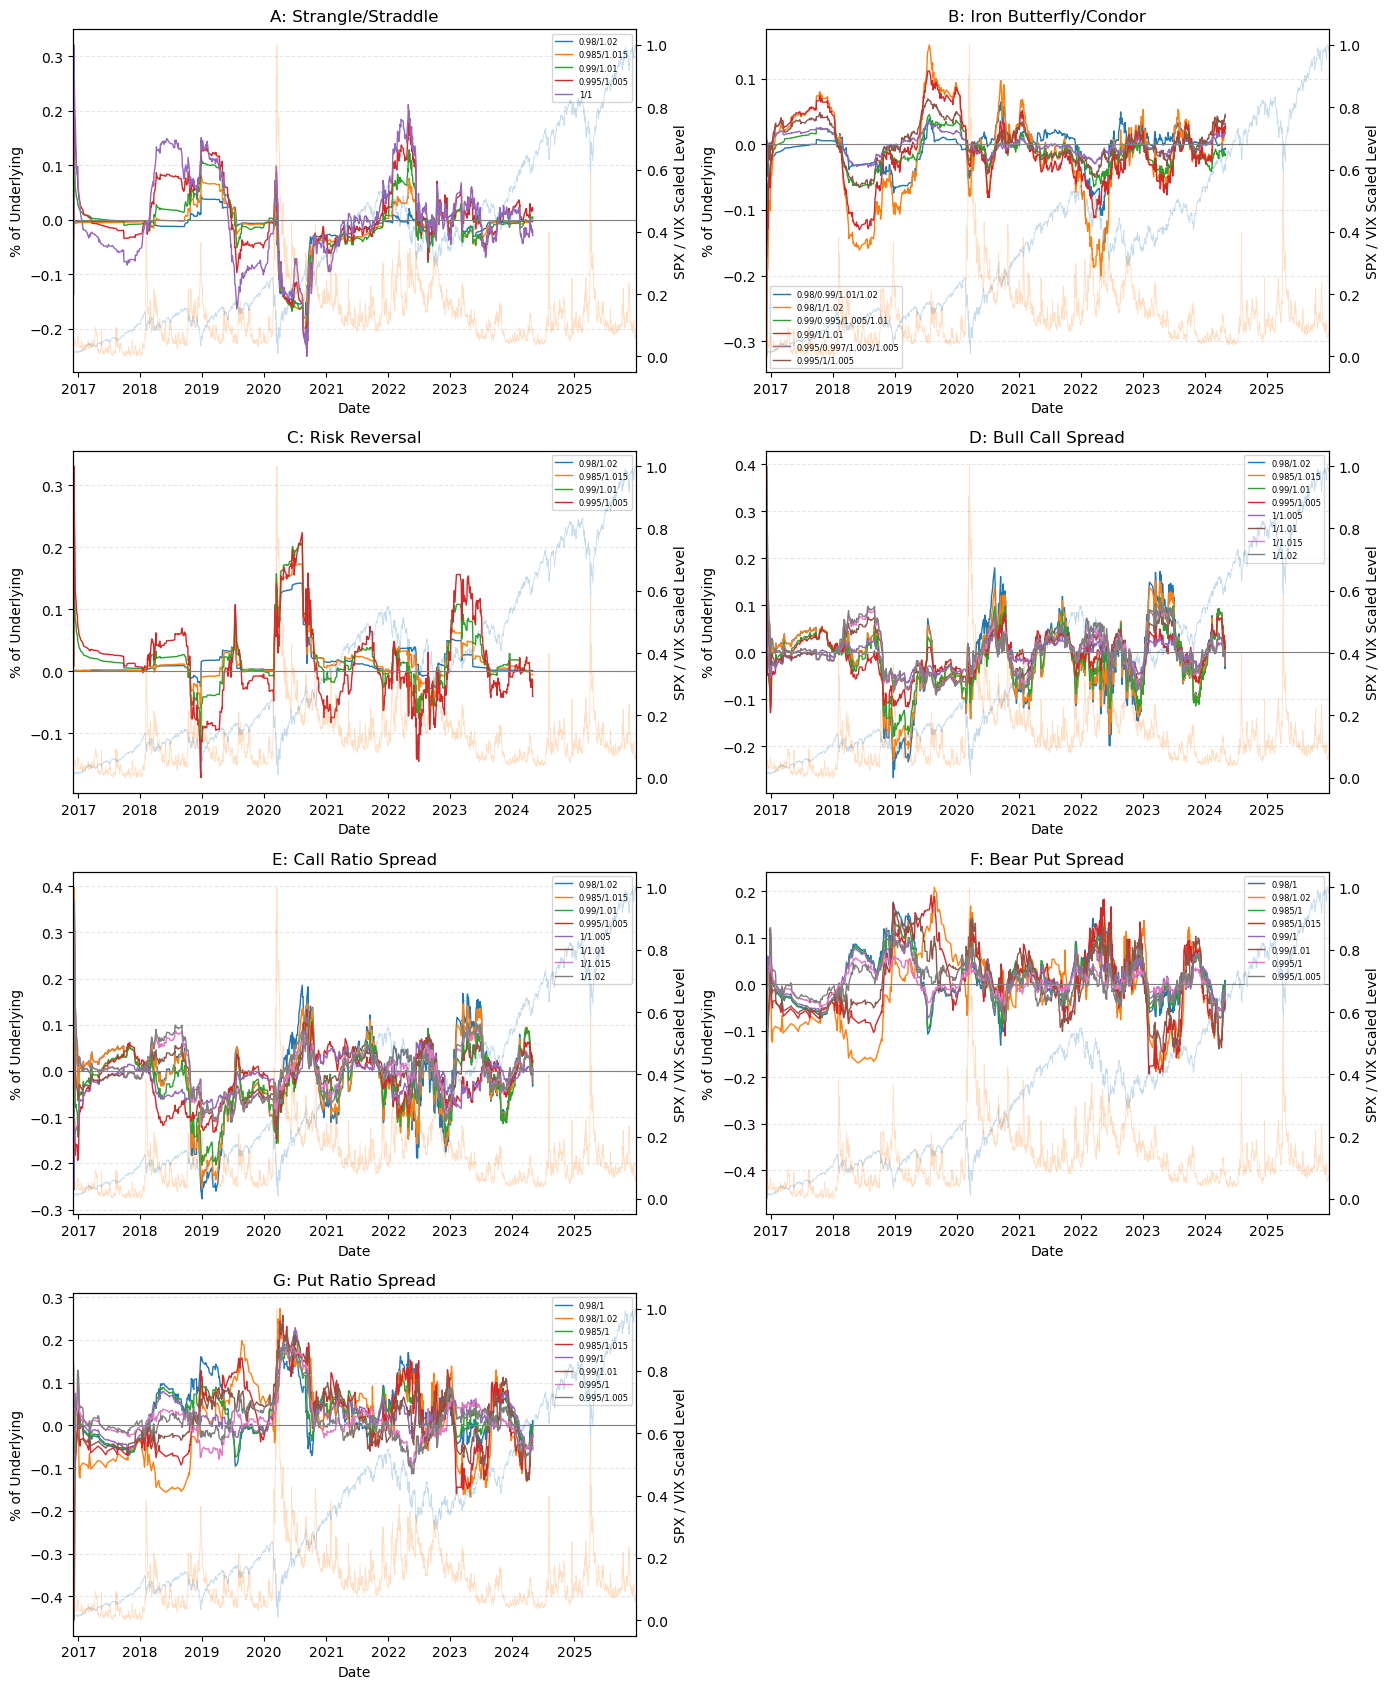

In [39]:

# ------------------------------------------------------------
# 1. PAPER SAMPLE WINDOW
# ------------------------------------------------------------

start_date = pd.Timestamp("2016-12-01")
end_date   = pd.Timestamp("2025-12-31")


# ------------------------------------------------------------
# 2. KEEP 10:00 STRATEGY OBSERVATIONS
# ------------------------------------------------------------

strat10 = df_strat[
    (df_strat["time"] == "10:00:00") &
    (df_strat["quote_date"] >= start_date) &
    (df_strat["quote_date"] <= end_date)
].copy()

strat10["mnes"] = strat10["mnes"].astype(str)


# ------------------------------------------------------------
# 3. RESTRICT SPX/VIX TO SAME SAMPLE WINDOW
# ------------------------------------------------------------

eod = df_eod[
    (df_eod["Date"] >= start_date) &
    (df_eod["Date"] <= end_date)
].copy()


spx = (
    eod[eod["root"] == "SPX"]
    .set_index("Date")["Close"]
    .sort_index()
)

vix = (
    eod[eod["root"] == "VIX"]
    .set_index("Date")["Close"]
    .sort_index()
)


# ------------------------------------------------------------
# 4. SCALE SPX AND VIX TO 0–1
# ------------------------------------------------------------

spx_scaled = (
    (spx - spx.min()) /
    (spx.max() - spx.min())
)

vix_scaled = (
    (vix - vix.min()) /
    (vix.max() - vix.min())
)


# ------------------------------------------------------------
# 5. STRATEGY LABELS
# ------------------------------------------------------------

STRATEGY_LABELS = {
    "strangle": "Strangle/Straddle",
    "iron_condor": "Iron Butterfly/Condor",
    "risk_reversal": "Risk Reversal",
    "bull_call_spread": "Bull Call Spread",
    "call_ratio_spread": "Call Ratio Spread",
    "bear_put_spread": "Bear Put Spread",
    "put_ratio_spread": "Put Ratio Spread"
}


# ------------------------------------------------------------
# 6. CREATE FIGURE
# ------------------------------------------------------------

fig, axes = plt.subplots(
    4,
    2,
    figsize=(14, 17)
)

axes = axes.flatten()


# ------------------------------------------------------------
# 7. LOOP OVER STRATEGIES
# ------------------------------------------------------------

for i, (strategy, label) in enumerate(
    STRATEGY_LABELS.items()
):

    ax = axes[i]

    temp = strat10[
        strat10["option_type"] == strategy
    ].copy()


    # Sort correctly before rolling
    temp = temp.sort_values(
        ["mnes", "quote_date"]
    )


    # --------------------------------------------------------
    # 63-observation moving average
    # --------------------------------------------------------

    temp["roll63"] = (
        temp
        .groupby("mnes")["reth_und"]
        .transform(
            lambda x:
            x.rolling(
                window=63,
                min_periods=1
            ).mean()
        )
    )


    # --------------------------------------------------------
    # Plot each moneyness structure
    # --------------------------------------------------------

    for mnes, group in temp.groupby("mnes"):

        ax.plot(
            group["quote_date"],
            group["roll63"],
            linewidth=1,
            label=mnes
        )


    # Zero line
    ax.axhline(
        0,
        color="gray",
        linewidth=0.8
    )


    # --------------------------------------------------------
    # Add SPX/VIX on second axis
    # --------------------------------------------------------

    ax2 = ax.twinx()

    ax2.plot(
        spx_scaled.index,
        spx_scaled.values,
        linewidth=0.6,
        alpha=0.25,
        label="SPX"
    )

    ax2.plot(
        vix_scaled.index,
        vix_scaled.values,
        linewidth=0.6,
        alpha=0.25,
        label="VIX"
    )


    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------

    ax.set_title(
        f"{chr(65+i)}: {label}"
    )

    ax.set_xlabel(
        "Date"
    )

    ax.set_ylabel(
        "% of Underlying"
    )

    ax2.set_ylabel(
        "SPX / VIX Scaled Level"
    )


    # Force paper sample on x-axis
    ax.set_xlim(
        start_date,
        end_date
    )


    # Grid
    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )


    # Strategy legend
    ax.legend(
        fontsize=6,
        loc="best"
    )


# Hide unused panel
axes[7].axis("off")


# ------------------------------------------------------------
# 8. FINAL LAYOUT
# ------------------------------------------------------------

plt.tight_layout()


# ------------------------------------------------------------
# 9. SAVE FIGURE
# ------------------------------------------------------------

plt.savefig(
    fig_dir / "Figure5_Moving_PNL_corrected.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    fig_dir / "Figure5_Moving_PNL_corrected.pdf",
    bbox_inches="tight"
)


# ------------------------------------------------------------
# 10. DISPLAY
# ------------------------------------------------------------

plt.show()